<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/stellar_spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spectral Analysis of Stars (with SSDS)**

In [1]:
!pip install astroquery astropy matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 25.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astroquery.sdss import SDSS
from astropy.io import fits

In [3]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from astropy import units as u

# Define the target coordinates (determine coordinates)
ra = 148.97083333
dec = 16.43222222

# Create a SkyCoord object
pos = coords.SkyCoord(ra=ra, dec=dec, unit='deg')

# Query SDSS for spectra
xid = SDSS.query_region(pos, spectro=True, radius=0.02 * u.deg)

# Check if any spectra were found
if xid is not None and len(xid) > 0:
    # Extract the identifiers from the first result (iterate if there are multiple)
    plate = xid['plate'][0]
    mjd = xid['mjd'][0]
    fiberID = xid['fiberID'][0]

    # Retrieve the spectrum using the identifiers
    sp = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberID)

    # Access the spectrum data
    flux = sp[0][1].data['flux']
    wavelength = 10**sp[0][1].data['loglam']

    # Print the first few data points (for demonstration)
    print("Wavelength (Angstroms) | Flux")
    for i in range(5):
        print(f"{wavelength[i]:.2f} | {flux[i]:.2f}")

else:
    print("No spectra found in the queried region.")

Wavelength (Angstroms) | Flux
3578.49 | 17.94
3579.32 | 13.18
3580.14 | 8.41
3580.96 | 2.94
3581.79 | 0.06


In [4]:
# Print the FITS Header Information from Sloan Digital Sky Survey (SDSS)
print(sp[0][1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   32 / length of dimension 1                          NAXIS2  =                 4573 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    8 / number of table fields                         TTYPE1  = 'flux    '                                                            TFORM1  = 'E       '                                                            TTYPE2  = 'loglam  '                                                            TFORM2  = 'E       '                                                            TTYPE3  = 'ivar    '                    

In [5]:
# Print shape and data types
print("Flux shape:", flux.shape)
print("Flux data type:", flux.dtype)
print("Wavelength shape:", wavelength.shape)
print("Wavelength data type:", wavelength.dtype)

Flux shape: (4573,)
Flux data type: >f4
Wavelength shape: (4573,)
Wavelength data type: float32


In [11]:
from astropy.table import Table

# Flux: amount of light energy received per unit area from an astronomical object
# Typically measured in units of ergs per second per square centimeter (erg/s/cm²)

# Flux is an important observational quantity as it indicates the brightness of objects like stars, galaxies, and quasars, as seen from Earth.
# Flux data is used to study the physical properties of astronomical objects, including their distances, sizes, and compositions.

# In SDSS, flux is measured across different filters (bands), typically labeled as u, g, r, i, z,
# corresponding to different parts of the electromagnetic spectrum, ranging from ultraviolet (u) to infrared (z).
# Flux values are used to estimate magnitudes, which describe how bright an object appears.

# Create an astropy Table
spectrum_table = Table([wavelength, flux], names=['wavelength', 'flux'])

# Print the first few rows
print(spectrum_table[:5])

wavelength    flux   
---------- ----------
 3578.4915  17.944094
 3579.3167  13.178341
   3580.14   8.412274
 3580.9636  2.9396217
 3581.7893 0.06172952


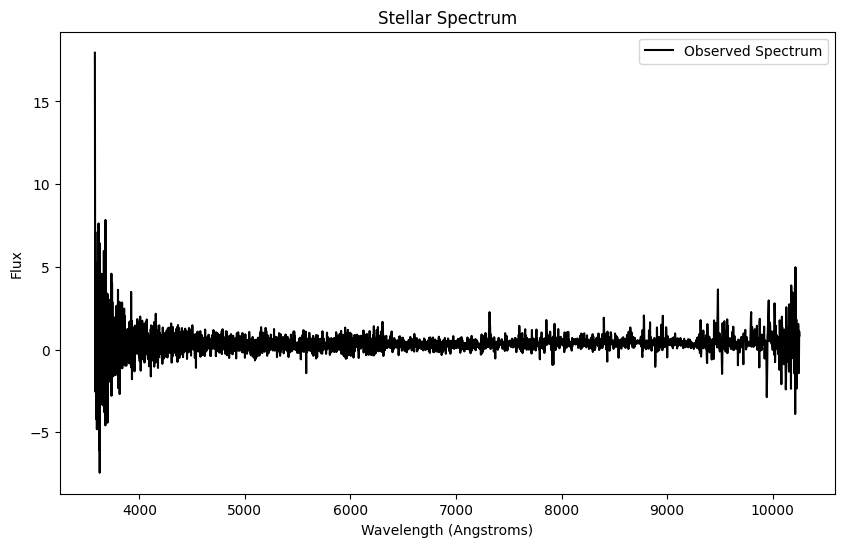

In [7]:
# Visualize the Spectrum
plt.figure(figsize=(10, 6))
plt.plot(wavelength, flux, 'k-', label='Observed Spectrum')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux')
plt.title('Stellar Spectrum')
plt.legend()
plt.show()

**Spectra like this are used to categorize stars, galaxies, and other celestial objects by comparing them to known spectral standards**
* range of wavelengths in Angstroms covers approximately 3500 to 11000 Angstroms - corresponds to optical and near-infrared electromagnetic spectrum.
* specific wavelength bands help identify chemical elements present in star's atmosphere through their absorption and emission lines (check for specific lines like hydrogen alpha at 6563 Å or calcium lines)
* flux indicates the amount of light received from an object at different wavelengths. Positive values represent amount of light observed, negative values suggest noise, uncertainties, or some instrumental effect.
* large variations in flux at certain wavelengths, particularly in ultraviolet region (left plot side), indicate prominent spectral features like hydrogen lines (e.g., Balmer series).
* Relatively flat region in the middle suggests a stable portion of the star's spectrum, potentially dominated by blackbody radiation.
* Sharp drops in flux may represent absorption lines, where light is absorbed by certain elements (e.g., hydrogen, helium, or metals).
* Peaks or sharp rises may indicate emission lines, where light is emitted at specific wavelengths by excited atoms in star's atmosphere
* other information might be included, like further chemical composition, temperature, and maybe its motion (from Doppler shifts in lines)

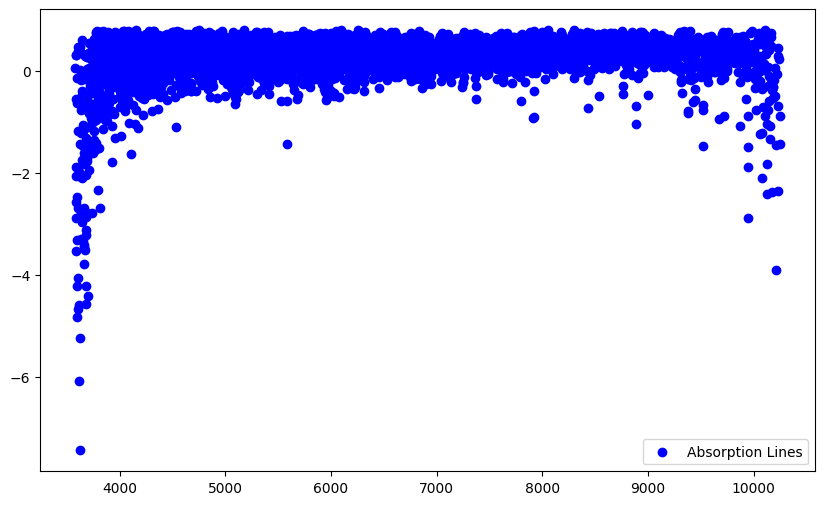

In [10]:
# Identify Spectral Lines (Simplified, finds absorption lines based on flux theeshold)
# (Normally, use line lists and sophisticated algorithms
absorption_lines = np.where(flux < 0.8)[0]  # Assuming strong lines have flux < 0.8
plt.figure(figsize=(10, 6))
plt.scatter(wavelength[absorption_lines], flux[absorption_lines], color='b', marker='o', label='Absorption Lines')
plt.legend()
plt.show()